# emp_model_v6

**Starting point:** v4.1 (92.05%) — the best version.

**Two new pillars, everything else carried forward from v4.1:**

### Pillar 3 — Fixed multi-stream (per-stream projection, late fusion)
v5 concatenated 3 streams into 10496-d and compressed it 10496→2048 in one layer — too aggressive.
v6 projects each stream independently to a lower dimension before concatenating:
- Full image (3840-d, v4.1 fine-tuned C-RADIO, 8 views + patch) → project 1024-d
- Portrait crop (2560-d, v5 extraction, 4 views) → project 512-d
- Legend ring (2560-d, v5 extraction, 4 views) → project 512-d
- Concatenate: 2048-d → 3-layer MLP body → ArcFace (same capacity as v4.1)

No new extraction needed — reuses `cradio_v41_embeddings.pt` and `cradio_v5_crops.pt`.

### Pillar 4 — Two-stage hard-pair sub-classifiers
The 3 persistent confusion clusters have been stuck since v3:
- QAC: QUINTILLUS / AURELIAN / CLAUDIUS GOTHICUS
- VAG: VALERIAN / AEMILIAN / GALLIENUS
- SDP: SEPTIMUS SEVERUS / DIDIUS JULIANUS / PERTINAX

A specialized sub-classifier (5-head ensemble, ArcFace margin=0.4 for tighter separation)
is trained on each cluster. At inference, for samples predicted within a cluster, the
main ensemble's cluster mass is redistributed according to the sub-classifier's distribution.

**Kept from v4.1:** ArcFace (m=0.2), 3-layer MLP, diverse ensemble hyperparams,
cluster-aware hard mixup, class-balanced sampling, hierarchical dynasty classifier.

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, math, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from datetime import datetime
from pathlib import Path
from PIL import Image

In [46]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab — skipping drive.mount.')

Not running on Colab — skipping drive.mount.


In [47]:
if ON_COLAB:
    DATA_DIR = r'/content/drive/MyDrive/coin_dataset'
else:
    DATA_DIR = r'/home/david/coin/FOR_TRAINNING'

In [48]:
def folder_label(name):
    return re.sub(r'^\d+_', '', name)

unique_labels = sorted({folder_label(p.name) for p in Path(DATA_DIR).iterdir()
                        if p.is_dir() and (p / 'side_a').exists()})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
num_classes   = len(label_encoder)
print(f'{num_classes} classes from folder structure.')

52 classes from folder structure.


In [49]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda:0


## Load 3-stream features (no extraction needed)

All embeddings were pre-computed in v4.1 and v5:
- `cradio_v41_embeddings.pt` — 3840-d full-image features (8 TTA views + patch tokens, fine-tuned C-RADIO)
- `cradio_v5_crops.pt` — 2560-d portrait crop + 2560-d legend ring (4 TTA views each, fine-tuned C-RADIO)

In [50]:
v41_path   = Path(DATA_DIR) / 'cradio_v41_embeddings.pt'
crops_path = Path(DATA_DIR) / 'cradio_v5_crops.pt'

v41_data   = torch.load(v41_path)
crops_data = torch.load(crops_path)

assert torch.equal(v41_data['labels'], crops_data['labels']), \
    'Label mismatch between cradio_v41 and cradio_v5_crops!'

feats_full     = v41_data['features']                  # (N, 3840)
feats_portrait = crops_data['features_portrait']       # (N, 2560)
feats_legend   = crops_data['features_legend']         # (N, 2560)
all_labs       = v41_data['labels']

print(f'Full:     {feats_full.shape}')
print(f'Portrait: {feats_portrait.shape}')
print(f'Legend:   {feats_legend.shape}')
print(f'Labels:   {all_labs.shape}')

Full:     torch.Size([62134, 3840])
Portrait: torch.Size([62134, 2560])
Legend:   torch.Size([62134, 2560])
Labels:   torch.Size([62134])


In [51]:
# Same label merge as all versions
MERGES = {'GORDIAN II': 'GORDIAN I'}

remap  = {label_encoder[src]: label_encoder[tgt] for src, tgt in MERGES.items()}
mapped = all_labs.clone()
for src_idx, tgt_idx in remap.items():
    mapped[all_labs == src_idx] = tgt_idx

kept_names        = [n for n in unique_labels if n not in MERGES]
new_label_encoder = {name: i for i, name in enumerate(kept_names)}
old_to_new        = {label_encoder[name]: new_label_encoder[name] for name in kept_names}

all_labs      = torch.tensor([old_to_new[int(x)] for x in mapped], dtype=torch.long)
label_encoder = new_label_encoder
idx_to_label  = {v: k for k, v in label_encoder.items()}
num_classes   = len(label_encoder)
print(f'After merge: {num_classes} classes.')

After merge: 51 classes.


In [52]:
# Stratified split — identical seeds to all prior versions for comparable test sets
(train_full,     test_full,
 train_portrait, test_portrait,
 train_legend,   test_legend,
 train_labs,     test_labs) = train_test_split(
    feats_full, feats_portrait, feats_legend, all_labs,
    test_size=0.2, shuffle=True, stratify=all_labs, random_state=42)

(train_full,     val_full,
 train_portrait, val_portrait,
 train_legend,   val_legend,
 train_labs,     val_labs) = train_test_split(
    train_full, train_portrait, train_legend, train_labs,
    test_size=0.2, shuffle=True, stratify=train_labs, random_state=42)

FULL_DIM     = train_full.shape[1]       # 3840
PORTRAIT_DIM = train_portrait.shape[1]   # 2560
LEGEND_DIM   = train_legend.shape[1]     # 2560

print(f'Train: {len(train_labs)}  Val: {len(val_labs)}  Test: {len(test_labs)}')
print(f'Full dim: {FULL_DIM}  Portrait: {PORTRAIT_DIM}  Legend: {LEGEND_DIM}')

class_counts  = torch.bincount(train_labs, minlength=num_classes).float()
beta          = 0.9999
effective_num = 1.0 - torch.pow(beta, class_counts)
cb_weights    = (1.0 - beta) / effective_num
cb_weights    = cb_weights / cb_weights.sum() * num_classes
cb_weights    = cb_weights.to(device)
print('Class-balanced weights ready.')

Train: 39765  Val: 9942  Test: 12427
Full dim: 3840  Portrait: 2560  Legend: 2560
Class-balanced weights ready.


In [53]:
batch_size     = 512
sample_weights = cb_weights.cpu()[train_labs]
train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(train_labs),
                                        replacement=True)

train_loader = DataLoader(
    TensorDataset(train_full, train_portrait, train_legend, train_labs),
    batch_size=batch_size, sampler=train_sampler)
val_loader   = DataLoader(
    TensorDataset(val_full,   val_portrait,   val_legend,   val_labs),
    batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(
    TensorDataset(test_full,  test_portrait,  test_legend,  test_labs),
    batch_size=batch_size, shuffle=False)
print('Loaders ready.')

Loaders ready.


## Model — CoinHeadV6: per-stream projectors + late fusion + ArcFace

Each stream gets its own single-layer projection head before concatenation.
This prevents the aggressive 10496→2048 bottleneck that caused v5's regression.

```
full(3840) ──[LN→L(3840→1024)→G→D]──┐
portrait(2560) ─[LN→L(2560→512)→G→D]──┤ cat(2048) → body(2048→2048→1024) → ArcFace[51]
legend(2560) ──[LN→L(2560→512)→G→D]──┘
```

The body has identical capacity to v4.1's 3-layer MLP.

In [54]:
class ArcFaceClassifier(nn.Module):
    """Identical to v4.1. Sub-heads override margin=0.4 for harder intra-cluster separation."""
    def __init__(self, in_dim, n_cls, scale=20.0, margin=0.2):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_cls, in_dim))
        nn.init.xavier_uniform_(self.weight)
        self.scale  = scale
        self.margin = margin

    def forward(self, x, labels=None):
        x   = F.normalize(x, dim=-1)
        w   = F.normalize(self.weight, dim=-1)
        cos = x @ w.T
        if labels is None or not self.training:
            return self.scale * cos
        theta      = cos.clamp(-1 + 1e-7, 1 - 1e-7).acos()
        target_cos = (theta + self.margin).cos()
        one_hot    = torch.zeros_like(cos).scatter_(1, labels.unsqueeze(1), 1.0)
        return self.scale * (one_hot * target_cos + (1 - one_hot) * cos)


class StreamProjector(nn.Module):
    """Single-layer projection for one feature stream."""
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.proj(x)


class CoinHeadV6(nn.Module):
    """
    Per-stream projection → late fusion → 3-layer MLP → ArcFace.

    Projection: full(3840→1024) + portrait(2560→512) + legend(2560→512) → concat 2048-d
    Body:       2048 → 2048 → 1024  (same capacity as v4.1's 3840 → 2048 → 2048 → 1024)
    """
    def __init__(self, n_cls,
                 full_dim=3840, portrait_dim=2560, legend_dim=2560,
                 proj_full=1024, proj_crop=512,
                 hidden=2048, dropout=0.3):
        super().__init__()
        self.proj_full     = StreamProjector(full_dim,     proj_full, dropout=0.1)
        self.proj_portrait = StreamProjector(portrait_dim, proj_crop, dropout=0.1)
        self.proj_legend   = StreamProjector(legend_dim,   proj_crop, dropout=0.1)

        fused_dim = proj_full + proj_crop + proj_crop   # 2048
        self.body = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.cls = ArcFaceClassifier(hidden // 2, n_cls)

    def _fuse(self, x_full, x_portrait, x_legend):
        return torch.cat([
            self.proj_full(x_full),
            self.proj_portrait(x_portrait),
            self.proj_legend(x_legend),
        ], dim=-1)

    def forward(self, x_full, x_portrait, x_legend, labels=None):
        return self.cls(self.body(self._fuse(x_full, x_portrait, x_legend)), labels)


print(f'CoinHeadV6:')
print(f'  proj: full({FULL_DIM}→1024) + portrait({PORTRAIT_DIM}→512) + legend({LEGEND_DIM}→512) → 2048')
print(f'  body: 2048 → 2048 → 1024 → ArcFace[{num_classes}]  (m=0.2, s=20)')

CoinHeadV6:
  proj: full(3840→1024) + portrait(2560→512) + legend(2560→512) → 2048
  body: 2048 → 2048 → 1024 → ArcFace[51]  (m=0.2, s=20)


## Training utilities (identical to v4.1)

Cluster-aware hard mixup applies the **same** permutation and lambda to all 3 streams simultaneously,
so each mixed sample is a consistent blend across all feature views.

In [55]:
HARD_CLUSTERS = [
    ['QUINTILLUS', 'AURELIAN', 'CLAUDIUS GOTHICUS'],
    ['VALERIAN', 'AEMILIAN', 'GALLIENUS'],
    ['SEPTIMUS SEVERUS', 'DIDIUS JULIANUS', 'PERTINAX'],
    ['CARACALLA', 'GETA', 'ELAGABALUS', 'SEVERUS ALEXANDER'],
    ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
    ['PHILIP THE ARAB', 'TRAJAN DECIUS', 'TRBONIANUS GALLUS'],
    ['VESPASIAN', 'TITUS'],
    ['NUMERIAN', 'CARINUS', 'CARUS'],
]

cluster_affinity = torch.zeros(num_classes, num_classes, dtype=torch.bool)
for cluster in HARD_CLUSTERS:
    idxs = [label_encoder[n] for n in cluster if n in label_encoder]
    for a in idxs:
        for b in idxs:
            if a != b:
                cluster_affinity[a, b] = True


def cluster_aware_mixup(x_full, x_portrait, x_legend, y, alpha=0.3, hard_prob=0.2):
    """Same permutation and lambda applied to all 3 streams for consistency."""
    lam = float(np.random.beta(alpha, alpha))
    B   = x_full.size(0)
    idx = torch.randperm(B, device=x_full.device)

    if np.random.random() < hard_prob:
        affinities = cluster_affinity[y.cpu()]
        for i in range(B):
            partners = (affinities[i, y.cpu()] & (torch.arange(B) != i)).nonzero(as_tuple=True)[0]
            if len(partners) > 0:
                idx[i] = partners[torch.randint(len(partners), (1,))]

    mx_full     = lam * x_full     + (1 - lam) * x_full[idx]
    mx_portrait = lam * x_portrait + (1 - lam) * x_portrait[idx]
    mx_legend   = lam * x_legend   + (1 - lam) * x_legend[idx]
    return mx_full, mx_portrait, mx_legend, y, y[idx], lam


def arcface_mixup_loss(logits, y_a, y_b, lam, weight, smoothing=0.05):
    log_p = F.log_softmax(logits, dim=-1)
    def one(y):
        nll    = -log_p.gather(1, y.unsqueeze(1)).squeeze(1)
        smooth = -log_p.mean(dim=-1)
        per_ex = (1 - smoothing) * nll + smoothing * smooth
        if weight is not None:
            per_ex = per_ex * weight[y]
        return per_ex.mean()
    return lam * one(y_a) + (1 - lam) * one(y_b)


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [56]:
# Same diverse configs as v4.1 — this beat seed-only diversity
HEAD_CONFIGS = [
    # (seed, hidden, dropout, mixup_alpha, lr, weight_decay)
    (2000, 2048, 0.30, 0.20, 3e-4, 1e-2),
    (2001, 2048, 0.25, 0.15, 3e-4, 1e-2),
    (2002, 2048, 0.30, 0.20, 2e-4, 5e-3),
    (2003, 2048, 0.25, 0.20, 3e-4, 1e-2),
    (2004, 2048, 0.30, 0.15, 3e-4, 1e-2),
    (2005, 2048, 0.25, 0.20, 4e-4, 1e-2),
    (2006, 2048, 0.30, 0.20, 3e-4, 5e-3),
    (2007, 2048, 0.35, 0.15, 2e-4, 1e-2),
    (2008, 2048, 0.25, 0.20, 3e-4, 1e-2),
    (2009, 2048, 0.30, 0.20, 3e-4, 2e-2),
]
EPOCHS = 100


def train_one_head(seed, hidden=2048, dropout=0.3, mixup_alpha=0.2,
                   lr=3e-4, weight_decay=1e-2, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model     = CoinHeadV6(num_classes, hidden=hidden, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps_per_epoch = len(train_loader)
    scheduler = make_scheduler(optimizer, epochs * steps_per_epoch,
                                warmup_steps=2 * steps_per_epoch)
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        t0 = datetime.now()
        model.train()
        running = 0.0
        for x_full, x_portrait, x_legend, targets in train_loader:
            x_full     = x_full.to(device)
            x_portrait = x_portrait.to(device)
            x_legend   = x_legend.to(device)
            targets    = targets.to(device)
            (mx_full, mx_portrait, mx_legend,
             y_a, y_b, lam) = cluster_aware_mixup(
                x_full, x_portrait, x_legend, targets,
                alpha=mixup_alpha, hard_prob=0.2)
            optimizer.zero_grad()
            margin_labels = y_a if lam > 0.5 else None
            logits = model(mx_full, mx_portrait, mx_legend, margin_labels)
            loss   = arcface_mixup_loss(logits, y_a, y_b, lam, cb_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running += loss.item()

        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for x_full, x_portrait, x_legend, targets in val_loader:
                x_full, x_portrait, x_legend, targets = (
                    x_full.to(device), x_portrait.to(device),
                    x_legend.to(device), targets.to(device))
                v_correct += (model(x_full, x_portrait, x_legend).argmax(-1)
                              == targets).sum().item()
                v_total   += targets.size(0)
        val_acc  = v_correct / v_total
        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())

        if verbose and (epoch <= 5 or epoch % 10 == 0 or improved):
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[seed {seed}] ep {epoch:3d}/{epochs}  '
                  f'loss {running / len(train_loader):.4f}  '
                  f'val {val_acc:.4f}  lr {lr_now:.2e}  '
                  f'[{datetime.now() - t0}]' + (' <--' if improved else ''))

    model.load_state_dict(best_state)
    return model, best_val_acc


ensemble = []
for k, (seed, hidden, dropout, alpha, lr, wd) in enumerate(HEAD_CONFIGS):
    print(f'\n=== Head {k + 1}/{len(HEAD_CONFIGS)}  '
          f'hidden={hidden} drop={dropout} α={alpha} lr={lr:.0e} ===')
    m, vacc = train_one_head(seed, hidden, dropout, alpha, lr, wd,
                              verbose=(k == 0))
    print(f'  → best val acc: {vacc:.4f}')
    ensemble.append(m.eval())

torch.save([m.state_dict() for m in ensemble], '/home/david/coin/weights/emp_model_v6_ensemble.pth')
print(f'\nSaved {len(ensemble)} heads → /home/david/coin/weights/emp_model_v6_ensemble.pth')


=== Head 1/10  hidden=2048 drop=0.3 α=0.2 lr=3e-04 ===
[seed 2000] ep   1/100  loss 3.0180  val 0.8423  lr 1.50e-04  [0:00:02.648385] <--
[seed 2000] ep   2/100  loss 1.8107  val 0.8476  lr 3.00e-04  [0:00:01.663720] <--
[seed 2000] ep   3/100  loss 1.5528  val 0.8865  lr 3.00e-04  [0:00:01.722266] <--
[seed 2000] ep   4/100  loss 1.5512  val 0.8934  lr 3.00e-04  [0:00:01.899351] <--
[seed 2000] ep   5/100  loss 1.4085  val 0.8890  lr 2.99e-04  [0:00:01.725021]
[seed 2000] ep   6/100  loss 1.4182  val 0.8952  lr 2.99e-04  [0:00:01.869080] <--
[seed 2000] ep   7/100  loss 1.3089  val 0.8954  lr 2.98e-04  [0:00:01.858328] <--
[seed 2000] ep   9/100  loss 1.4224  val 0.8988  lr 2.96e-04  [0:00:01.722925] <--
[seed 2000] ep  10/100  loss 1.1696  val 0.9049  lr 2.95e-04  [0:00:01.658497] <--
[seed 2000] ep  13/100  loss 1.1919  val 0.9070  lr 2.91e-04  [0:00:01.816065] <--
[seed 2000] ep  15/100  loss 1.0841  val 0.9077  lr 2.87e-04  [0:00:01.990198] <--
[seed 2000] ep  18/100  loss 1.2140

## Inference — three-way fusion

Same as v4.1. kNN uses all 3 streams concatenated (8320-d) for maximum discrimination.
Per-class temperature softens the kNN distribution for the known hard classes.

In [57]:
@torch.no_grad()
def ensemble_probs(x_full, x_portrait, x_legend):
    x_full     = x_full.to(device)
    x_portrait = x_portrait.to(device)
    x_legend   = x_legend.to(device)
    probs = None
    for m in ensemble:
        p     = F.softmax(m(x_full, x_portrait, x_legend), dim=-1)
        probs = p if probs is None else probs + p
    return probs / len(ensemble)


# kNN over combined 8320-d space
train_combined = torch.cat([train_full, train_portrait, train_legend], dim=-1).to(device)
train_norm_all = F.normalize(train_combined, dim=-1)
train_labs_dev = train_labs.to(device)
COMBINED_DIM   = train_combined.shape[1]   # 8320

prototypes = torch.zeros(num_classes, COMBINED_DIM, device=device)
for c in range(num_classes):
    mask = train_labs_dev == c
    if mask.sum() > 0:
        prototypes[c] = F.normalize(train_norm_all[mask].mean(0), dim=-1)
print(f'Prototypes: {prototypes.shape}')

HARD_CLASS_NAMES = {
    'QUINTILLUS', 'VALERIAN', 'AEMILIAN', 'GALLIENUS',
    'SEPTIMUS SEVERUS', 'CLAUDIUS GOTHICUS', 'AURELIAN',
}
GLOBAL_TEMP    = 20.0
HARD_TEMP      = 8.0
per_class_temp = torch.full((num_classes,), GLOBAL_TEMP, device=device)
for name in HARD_CLASS_NAMES:
    if name in label_encoder:
        per_class_temp[label_encoder[name]] = HARD_TEMP


@torch.no_grad()
def proto_knn_probs(combined_feats):
    q      = F.normalize(combined_feats.to(device), dim=-1)
    sims   = q @ prototypes.T
    scaled = sims * per_class_temp.unsqueeze(0)
    return F.softmax(scaled, dim=-1)


@torch.no_grad()
def raw_knn_probs(combined_feats, K=25, temperature=20.0):
    q    = F.normalize(combined_feats.to(device), dim=-1)
    sims = q @ train_norm_all.T
    vals, idx = sims.topk(K, dim=-1)
    weights   = F.softmax(vals * temperature, dim=-1)
    neigh_labs = train_labs_dev[idx]
    out = torch.zeros(q.size(0), num_classes, device=device)
    out.scatter_add_(1, neigh_labs, weights)
    return out


@torch.no_grad()
def fused_predict(x_full, x_portrait, x_legend, ap=0.2, ak=0.1):
    combined = torch.cat([x_full, x_portrait, x_legend], dim=-1)
    e = ensemble_probs(x_full, x_portrait, x_legend)
    p = proto_knn_probs(combined)
    k = raw_knn_probs(combined)
    return (1 - ap - ak) * e + ap * p + ak * k

Prototypes: torch.Size([51, 8960])


In [58]:
print('Sweeping fusion weights on val set...')
results = {}
for ap in [0.0, 0.1, 0.2, 0.3]:
    for ak in [0.0, 0.1, 0.2]:
        if ap + ak > 0.6:
            continue
        correct, total = 0, 0
        for x_full, x_portrait, x_legend, targets in val_loader:
            targets = targets.to(device)
            probs   = fused_predict(x_full, x_portrait, x_legend, ap, ak)
            correct += (probs.argmax(-1) == targets).sum().item()
            total   += targets.size(0)
        results[(ap, ak)] = correct / total
        print(f'  α_proto={ap:.1f}  α_knn={ak:.1f}  → val={correct / total:.4f}')

best_ap, best_ak = max(results, key=results.get)
print(f'\nBest: α_proto={best_ap}  α_knn={best_ak}  val={results[(best_ap, best_ak)]:.4f}')

Sweeping fusion weights on val set...
  α_proto=0.0  α_knn=0.0  → val=0.9186
  α_proto=0.0  α_knn=0.1  → val=0.9187
  α_proto=0.0  α_knn=0.2  → val=0.9186
  α_proto=0.1  α_knn=0.0  → val=0.9188
  α_proto=0.1  α_knn=0.1  → val=0.9188
  α_proto=0.1  α_knn=0.2  → val=0.9182
  α_proto=0.2  α_knn=0.0  → val=0.9190
  α_proto=0.2  α_knn=0.1  → val=0.9189
  α_proto=0.2  α_knn=0.2  → val=0.9179
  α_proto=0.3  α_knn=0.0  → val=0.9189
  α_proto=0.3  α_knn=0.1  → val=0.9191
  α_proto=0.3  α_knn=0.2  → val=0.9182

Best: α_proto=0.3  α_knn=0.1  val=0.9191


In [59]:
def evaluate_loader(loader, predict_fn, name):
    correct, total = 0, 0
    for x_full, x_portrait, x_legend, targets in loader:
        targets = targets.to(device)
        probs   = predict_fn(x_full, x_portrait, x_legend)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'  {name}: {acc:.4f}  ({correct}/{total})')
    return acc

print('--- Ensemble only ---')
evaluate_loader(val_loader,  ensemble_probs, 'Val  ')
evaluate_loader(test_loader, ensemble_probs, 'Test ')

print(f'\n--- Ensemble + proto-kNN + raw-kNN (α_p={best_ap}, α_k={best_ak}) ---')
evaluate_loader(val_loader,  lambda f,p,l: fused_predict(f,p,l,best_ap,best_ak), 'Val  ')
evaluate_loader(test_loader, lambda f,p,l: fused_predict(f,p,l,best_ap,best_ak), 'Test ')

--- Ensemble only ---
  Val  : 0.9186  (9133/9942)
  Test : 0.9199  (11432/12427)

--- Ensemble + proto-kNN + raw-kNN (α_p=0.3, α_k=0.1) ---
  Val  : 0.9191  (9138/9942)
  Test : 0.9199  (11431/12427)


0.9198519353021647

## Hierarchical dynasty classifier (same as v4.1)

Predicts one of 9 dynasty/period groups, then uses the dynasty probabilities as a soft
mask over emperor logits to reduce cross-period confusions. Uses full-image features only
(proven in v4.1).

In [60]:
DYNASTIES = {
    'JULIO_CLAUDIAN': ['AUGUSTUS', 'TIBERIUS', 'CALIGULA', 'CLAUDIUS', 'NERO'],
    'YEAR_OF_FOUR':   ['GALBA', 'OTHO', 'VITELLIUS'],
    'FLAVIAN':        ['VESPASIAN', 'TITUS', 'DOMITIAN'],
    'NERVA_ANTONINE': ['NERVA', 'TRAJAN', 'HADRIAN', 'ANTONINUS PIUS',
                       'MARCUS AURELIUS', 'LUCIUS VERUS'],
    'COMMODUS_CHAOS': ['COMMODUS', 'PERTINAX', 'DIDIUS JULIANUS'],
    'SEVERAN':        ['SEPTIMUS SEVERUS', 'CARACALLA', 'GETA', 'MACRINUS',
                       'ELAGABALUS', 'SEVERUS ALEXANDER'],
    'CRISIS_EARLY':   ['MAXIMINUS THRAX', 'GORDIAN I', 'PUPIENUS', 'BALBINUS',
                       'GORDIAN III', 'PHILIP THE ARAB', 'TRAJAN DECIUS',
                       'TRBONIANUS GALLUS', 'AEMILIAN'],
    'CRISIS_LATE':    ['VALERIAN', 'GALLIENUS', 'CLAUDIUS GOTHICUS', 'QUINTILLUS',
                       'AURELIAN', 'TACITUS', 'FLORIANUS', 'PROBUS',
                       'CARUS', 'NUMERIAN', 'CARINUS'],
    'TETRARCHY':      ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
}

dynasty_names      = sorted(DYNASTIES.keys())
dynasty_encoder    = {d: i for i, d in enumerate(dynasty_names)}
emperor_to_dynasty = {e: d for d, emps in DYNASTIES.items() for e in emps}

dynasty_of = torch.tensor(
    [dynasty_encoder.get(emperor_to_dynasty.get(idx_to_label[i], ''), 0)
     for i in range(num_classes)], dtype=torch.long
)
n_dynasties = len(dynasty_names)

def to_dynasty(emp_labs):
    return dynasty_of[emp_labs]

train_dyn_loader = DataLoader(
    TensorDataset(train_full, to_dynasty(train_labs)),
    batch_size=512, sampler=train_sampler)
val_dyn_loader   = DataLoader(
    TensorDataset(val_full, to_dynasty(val_labs)),
    batch_size=512, shuffle=False)

torch.manual_seed(42)
stage1 = nn.Sequential(
    nn.LayerNorm(FULL_DIM),
    nn.Linear(FULL_DIM, 512),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(512, n_dynasties),
).to(device)

opt1   = torch.optim.AdamW(stage1.parameters(), lr=3e-4, weight_decay=1e-2)
sched1 = make_scheduler(opt1, 60 * len(train_dyn_loader),
                         warmup_steps=2 * len(train_dyn_loader))

best_dyn_acc, best_dyn_state = 0.0, None
for epoch in range(1, 61):
    stage1.train()
    for feats, dyn_targets in train_dyn_loader:
        feats, dyn_targets = feats.to(device), dyn_targets.to(device)
        opt1.zero_grad()
        F.cross_entropy(stage1(feats), dyn_targets).backward()
        opt1.step(); sched1.step()

    stage1.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for feats, dyn_targets in val_dyn_loader:
            feats, dyn_targets = feats.to(device), dyn_targets.to(device)
            correct += (stage1(feats).argmax(-1) == dyn_targets).sum().item()
            total   += dyn_targets.size(0)
    acc = correct / total
    if acc > best_dyn_acc:
        best_dyn_acc  = acc
        best_dyn_state = copy.deepcopy(stage1.state_dict())
    if epoch % 10 == 0:
        print(f'  ep {epoch:2d}/60  val dynasty acc={acc:.4f}')

stage1.load_state_dict(best_dyn_state)
stage1.eval()
print(f'Best dynasty val acc: {best_dyn_acc:.4f}')

  ep 10/60  val dynasty acc=0.9557
  ep 20/60  val dynasty acc=0.9576
  ep 30/60  val dynasty acc=0.9575
  ep 40/60  val dynasty acc=0.9546
  ep 50/60  val dynasty acc=0.9556
  ep 60/60  val dynasty acc=0.9549
Best dynasty val acc: 0.9583


In [61]:
dynasty_mask = torch.zeros(n_dynasties, num_classes, dtype=torch.float, device=device)
for dyn, emps in DYNASTIES.items():
    d_idx = dynasty_encoder[dyn]
    for e in emps:
        if e in label_encoder:
            dynasty_mask[d_idx, label_encoder[e]] = 1.0


@torch.no_grad()
def hierarchical_predict(x_full, x_portrait, x_legend,
                          ap=best_ap, ak=best_ak, hier_weight=0.1):
    flat      = fused_predict(x_full, x_portrait, x_legend, ap, ak)
    dyn_probs = F.softmax(stage1(x_full.to(device)), dim=-1)
    soft_mask = dyn_probs @ dynasty_mask
    soft_mask = soft_mask / (soft_mask.sum(dim=-1, keepdim=True) + 1e-8)
    guided    = flat * soft_mask
    guided    = guided / (guided.sum(dim=-1, keepdim=True) + 1e-8)
    return (1 - hier_weight) * flat + hier_weight * guided


print('Sweeping hier_weight on val set...')
best_hw, best_hw_acc = 0.0, 0.0
for hw in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    correct, total = 0, 0
    for x_full, x_portrait, x_legend, targets in val_loader:
        targets = targets.to(device)
        probs   = hierarchical_predict(x_full, x_portrait, x_legend, hier_weight=hw)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'  hier_weight={hw:.1f}  val acc={acc:.4f}')
    if acc > best_hw_acc:
        best_hw_acc = acc; best_hw = hw

print(f'\nBest hier_weight: {best_hw}  val={best_hw_acc:.4f}')

Sweeping hier_weight on val set...
  hier_weight=0.0  val acc=0.9191
  hier_weight=0.1  val acc=0.9192
  hier_weight=0.2  val acc=0.9196
  hier_weight=0.3  val acc=0.9194
  hier_weight=0.4  val acc=0.9197
  hier_weight=0.5  val acc=0.9198

Best hier_weight: 0.5  val=0.9198


## Two-stage hard-pair sub-classifiers (Pillar 4 — new in v6)

Three confusion clusters have been stuck at the same error rate across all versions.
A specialized sub-classifier is trained on each cluster's samples with:
- **ArcFace margin=0.4** (vs 0.2 in the main head) — forces tighter separation within the cluster
- **5-head ensemble** with diverse dropout/lr configs
- **Input: v4.1 full-image features (3840-d)** — the proven best single representation
- **150 epochs** — more training for the harder, smaller dataset

**Inference:** When the main ensemble assigns mass to a cluster, that mass is redistributed
according to the sub-classifier's distribution. The blend weight `sub_weight` is tuned on val.

In [62]:
class SubHead(nn.Module):
    """
    Specialized 2-layer MLP for a small cluster of visually confusable classes.
    ArcFace margin=0.4 (double the main head's 0.2) forces tighter angular clusters.
    Input: v4.1 full-image features (3840-d).
    """
    def __init__(self, in_dim, n_cls, hidden=512, dropout=0.2,
                 margin=0.4, scale=25.0):
        super().__init__()
        self.body = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.cls = ArcFaceClassifier(hidden // 2, n_cls, scale=scale, margin=margin)

    def forward(self, x, labels=None):
        return self.cls(self.body(x), labels)


HARD_PAIR_CLUSTERS = {
    'QAC':         ['QUINTILLUS', 'AURELIAN', 'CLAUDIUS GOTHICUS'],
    'VAG':         ['VALERIAN', 'AEMILIAN', 'GALLIENUS'],
    'SDP':         ['SEPTIMUS SEVERUS', 'DIDIUS JULIANUS', 'PERTINAX'],
    'TETRARCHY':   ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
    'SEVERAN_HARD': ['ELAGABALUS', 'CARACALLA', 'GETA'],
}

SUB_HEAD_CONFIGS = [
    # (seed, dropout, lr, weight_decay)
    (4000, 0.20, 5e-4, 5e-3),
    (4001, 0.20, 3e-4, 1e-2),
    (4002, 0.25, 4e-4, 1e-2),
    (4003, 0.20, 3e-4, 5e-3),
    (4004, 0.25, 5e-4, 1e-2),
]
SUB_EPOCHS = 150
print(f'Sub-head architecture: {FULL_DIM} -> 512 -> 256 -> ArcFace(m=0.4, s=25)')
print(f'Clusters: {list(HARD_PAIR_CLUSTERS.keys())}')


Sub-head architecture: 3840 -> 512 -> 256 -> ArcFace(m=0.4, s=25)
Clusters: ['QAC', 'VAG', 'SDP', 'TETRARCHY', 'SEVERAN_HARD']


In [63]:
def train_sub_cluster(cluster_name, cluster_class_names):
    cluster_idxs  = [label_encoder[n] for n in cluster_class_names if n in label_encoder]
    local_encoder = {old_idx: new_idx for new_idx, old_idx in enumerate(cluster_idxs)}
    n_cluster     = len(cluster_idxs)
    print(f'\n--- {cluster_name}: {cluster_class_names}  ({n_cluster} classes) ---')

    def filter_cluster(feat_f, labs):
        mask  = torch.tensor([l.item() in cluster_idxs for l in labs], dtype=torch.bool)
        sub_f = feat_f[mask]
        sub_l = torch.tensor([local_encoder[l.item()] for l in labs[mask]],
                               dtype=torch.long)
        return sub_f, sub_l

    tr_f, tr_l = filter_cluster(train_full, train_labs)
    va_f, va_l = filter_cluster(val_full,   val_labs)
    print(f'  Train: {len(tr_l)}  Val: {len(va_l)}')
    for new_i, old_i in enumerate(cluster_idxs):
        n_tr = (tr_l == new_i).sum().item()
        n_va = (va_l == new_i).sum().item()
        print(f'  {idx_to_label[old_i]}: {n_tr} train / {n_va} val')

    sub_counts  = torch.bincount(tr_l, minlength=n_cluster).float()
    sub_eff     = 1.0 - torch.pow(0.9999, sub_counts)
    sub_cb_w    = (1.0 - 0.9999) / sub_eff
    sub_cb_w    = (sub_cb_w / sub_cb_w.sum() * n_cluster).to(device)
    sub_sw      = sub_cb_w.cpu()[tr_l]
    sub_sampler = WeightedRandomSampler(sub_sw, num_samples=len(tr_l), replacement=True)

    sub_bs = min(128, len(tr_l))
    sub_tr = DataLoader(TensorDataset(tr_f, tr_l), batch_size=sub_bs,
                         sampler=sub_sampler)
    sub_va = DataLoader(TensorDataset(va_f, va_l), batch_size=256, shuffle=False)

    sub_ensemble = []
    for k, (seed, dropout, lr, wd) in enumerate(SUB_HEAD_CONFIGS):
        torch.manual_seed(seed); np.random.seed(seed)
        model     = SubHead(FULL_DIM, n_cluster, dropout=dropout).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        scheduler = make_scheduler(optimizer, SUB_EPOCHS * len(sub_tr),
                                    warmup_steps=2 * len(sub_tr))
        best_va, best_state = 0.0, None

        for epoch in range(1, SUB_EPOCHS + 1):
            model.train()
            for x_batch, y_batch in sub_tr:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                lam = float(np.random.beta(0.2, 0.2))
                idx = torch.randperm(x_batch.size(0), device=device)
                x_mixed = lam * x_batch + (1 - lam) * x_batch[idx]
                y_a, y_b = y_batch, y_batch[idx]
                optimizer.zero_grad()
                margin_labels = y_a if lam > 0.5 else None
                logits = model(x_mixed, margin_labels)
                loss   = arcface_mixup_loss(logits, y_a, y_b, lam, sub_cb_w,
                                             smoothing=0.05)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for x_b, y_b in sub_va:
                    x_b, y_b = x_b.to(device), y_b.to(device)
                    correct += (model(x_b).argmax(-1) == y_b).sum().item()
                    total   += y_b.size(0)
            va_acc = correct / total
            if va_acc > best_va:
                best_va    = va_acc
                best_state = copy.deepcopy(model.state_dict())

        model.load_state_dict(best_state)
        model.eval()
        sub_ensemble.append(model)
        print(f'  head {k + 1}/{len(SUB_HEAD_CONFIGS)}  best val: {best_va:.4f}')

    return sub_ensemble, cluster_idxs


sub_classifiers = {}
for cluster_name, cluster_class_names in HARD_PAIR_CLUSTERS.items():
    sub_ens, cluster_idxs = train_sub_cluster(cluster_name, cluster_class_names)
    sub_classifiers[cluster_name] = {'ensemble': sub_ens, 'idxs': cluster_idxs}

sub_save = {
    name: {'states': [m.state_dict() for m in info['ensemble']], 'idxs': info['idxs']}
    for name, info in sub_classifiers.items()
}
torch.save(sub_save, '/home/david/coin/weights/emp_model_v6_sub.pth')
print('\nSaved sub-classifiers → /home/david/coin/weights/emp_model_v6_sub.pth')


--- QAC: ['QUINTILLUS', 'AURELIAN', 'CLAUDIUS GOTHICUS']  (3 classes) ---
  Train: 1545  Val: 386
  QUINTILLUS: 449 train / 112 val
  AURELIAN: 562 train / 141 val
  CLAUDIUS GOTHICUS: 534 train / 133 val
  head 1/5  best val: 0.7902
  head 2/5  best val: 0.7979
  head 3/5  best val: 0.8161
  head 4/5  best val: 0.8135
  head 5/5  best val: 0.8083

--- VAG: ['VALERIAN', 'AEMILIAN', 'GALLIENUS']  (3 classes) ---
  Train: 1402  Val: 350
  VALERIAN: 392 train / 98 val
  AEMILIAN: 488 train / 122 val
  GALLIENUS: 522 train / 130 val
  head 1/5  best val: 0.7600
  head 2/5  best val: 0.7429
  head 3/5  best val: 0.7400
  head 4/5  best val: 0.7457
  head 5/5  best val: 0.7600

--- SDP: ['SEPTIMUS SEVERUS', 'DIDIUS JULIANUS', 'PERTINAX']  (3 classes) ---
  Train: 3000  Val: 750
  SEPTIMUS SEVERUS: 1501 train / 375 val
  DIDIUS JULIANUS: 507 train / 127 val
  PERTINAX: 992 train / 248 val
  head 1/5  best val: 0.8360
  head 2/5  best val: 0.8360
  head 3/5  best val: 0.8360
  head 4/5  best 

## Two-stage inference

For each hard cluster, the main ensemble's assigned probability mass for that cluster is
redistributed according to the sub-classifier. `sub_weight` controls how much of the
redistribution to apply:
- `sub_weight=0.0` → ignore sub-classifiers (pure stage-1)
- `sub_weight=1.0` → fully replace cluster mass with sub-classifier distribution

The blend is applied to all 3 clusters simultaneously, then the full distribution is renormalized.

In [64]:
@torch.no_grad()
def sub_cluster_probs(x_full, cluster_name):
    """(B, N_cluster) softmax probs from the cluster's 5-head sub-ensemble."""
    x    = x_full.to(device)
    info = sub_classifiers[cluster_name]
    probs = None
    for m in info['ensemble']:
        p     = F.softmax(m(x), dim=-1)
        probs = p if probs is None else probs + p
    return probs / len(info['ensemble'])


@torch.no_grad()
def two_stage_predict(x_full, x_portrait, x_legend,
                       ap=best_ap, ak=best_ak, hier_weight=best_hw,
                       sub_weights=None):
    """
    Stage 1: main ensemble + kNN fusion + hierarchical dynasty.
    Stage 2: per-cluster sub-classifier redistribution.
    sub_weights: dict cluster_name -> float (0 = skip that cluster).
    """
    if sub_weights is None:
        sub_weights = {name: 0.0 for name in sub_classifiers}

    probs = hierarchical_predict(x_full, x_portrait, x_legend,
                                  ap=ap, ak=ak, hier_weight=hier_weight)

    for cluster_name, info in sub_classifiers.items():
        sw = sub_weights.get(cluster_name, 0.0)
        if sw == 0.0:
            continue

        cluster_idxs  = info['idxs']
        sub_p         = sub_cluster_probs(x_full, cluster_name)              # (B, N_c)
        cluster_mass  = probs[:, cluster_idxs].sum(dim=-1, keepdim=True)     # (B, 1)
        redistributed = cluster_mass * sub_p                                  # (B, N_c)
        blended       = (1 - sw) * probs[:, cluster_idxs] + sw * redistributed

        for local_i, global_i in enumerate(cluster_idxs):
            probs[:, global_i] = blended[:, local_i]

        probs = probs / (probs.sum(dim=-1, keepdim=True) + 1e-8)

    return probs


# Per-cluster independent weight sweep
print('Sweeping sub_weight per cluster (independent)...')
best_sw_per_cluster = {name: 0.0 for name in sub_classifiers}

for target_cluster in sub_classifiers:
    print(f'\n  [{target_cluster}]')
    best_sw, best_acc = 0.0, 0.0
    for sw in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        weights = {n: (sw if n == target_cluster else 0.0) for n in sub_classifiers}
        correct, total = 0, 0
        for x_full, x_portrait, x_legend, targets in val_loader:
            targets = targets.to(device)
            probs   = two_stage_predict(x_full, x_portrait, x_legend,
                                         sub_weights=weights)
            correct += (probs.argmax(-1) == targets).sum().item()
            total   += targets.size(0)
        acc = correct / total
        print(f'    sw={sw:.1f}  val={acc:.4f}')
        if acc > best_acc:
            best_acc = acc; best_sw = sw
    best_sw_per_cluster[target_cluster] = best_sw
    print(f'  -> best: {best_sw:.1f}  val={best_acc:.4f}')

print(f'\nPer-cluster best weights: {best_sw_per_cluster}')

correct, total = 0, 0
for x_full, x_portrait, x_legend, targets in val_loader:
    targets = targets.to(device)
    probs   = two_stage_predict(x_full, x_portrait, x_legend,
                                 sub_weights=best_sw_per_cluster)
    correct += (probs.argmax(-1) == targets).sum().item()
    total   += targets.size(0)
print(f'Combined val acc: {correct/total:.4f}')


Sweeping sub_weight per cluster (independent)...

  [QAC]
    sw=0.0  val=0.9198
    sw=0.1  val=0.9201
    sw=0.2  val=0.9201
    sw=0.3  val=0.9204
    sw=0.4  val=0.9205
    sw=0.5  val=0.9227
    sw=0.6  val=0.9236
    sw=0.7  val=0.9243
    sw=0.8  val=0.9243
    sw=0.9  val=0.9243
    sw=1.0  val=0.9242
  -> best: 0.7  val=0.9243

  [VAG]
    sw=0.0  val=0.9198
    sw=0.1  val=0.9198
    sw=0.2  val=0.9199
    sw=0.3  val=0.9201
    sw=0.4  val=0.9200
    sw=0.5  val=0.9208
    sw=0.6  val=0.9212
    sw=0.7  val=0.9213
    sw=0.8  val=0.9216
    sw=0.9  val=0.9217
    sw=1.0  val=0.9214
  -> best: 0.9  val=0.9217

  [SDP]
    sw=0.0  val=0.9198
    sw=0.1  val=0.9201
    sw=0.2  val=0.9207
    sw=0.3  val=0.9209
    sw=0.4  val=0.9213
    sw=0.5  val=0.9221
    sw=0.6  val=0.9220
    sw=0.7  val=0.9220
    sw=0.8  val=0.9222
    sw=0.9  val=0.9222
    sw=1.0  val=0.9221
  -> best: 0.8  val=0.9222

  [TETRARCHY]
    sw=0.0  val=0.9198
    sw=0.1  val=0.9198
    sw=0.2  val=0.9200


## Final results — all pipeline stages

In [65]:
print('=== FINAL V6 RESULTS ===\n')

print('--- Ensemble only (no kNN, no hier, no sub) ---')
evaluate_loader(val_loader,  ensemble_probs, 'Val  ')
evaluate_loader(test_loader, ensemble_probs, 'Test ')

print(f'\n--- + kNN fusion (alpha_p={best_ap}, alpha_k={best_ak}) ---')
evaluate_loader(val_loader,  lambda f,p,l: fused_predict(f,p,l,best_ap,best_ak), 'Val  ')
evaluate_loader(test_loader, lambda f,p,l: fused_predict(f,p,l,best_ap,best_ak), 'Test ')

print(f'\n--- + Hierarchical dynasty (w={best_hw}) ---')
evaluate_loader(val_loader,
    lambda f,p,l: hierarchical_predict(f,p,l,hier_weight=best_hw), 'Val  ')
evaluate_loader(test_loader,
    lambda f,p,l: hierarchical_predict(f,p,l,hier_weight=best_hw), 'Test ')

print(f'\n--- + Two-stage sub-classifiers (per-cluster weights={best_sw_per_cluster}) --- FULL PIPELINE ---')
evaluate_loader(val_loader,
    lambda f,p,l: two_stage_predict(f,p,l,sub_weights=best_sw_per_cluster), 'Val  ')
evaluate_loader(test_loader,
    lambda f,p,l: two_stage_predict(f,p,l,sub_weights=best_sw_per_cluster), 'Test ')


=== FINAL V6 RESULTS ===

--- Ensemble only (no kNN, no hier, no sub) ---
  Val  : 0.9186  (9133/9942)
  Test : 0.9199  (11432/12427)

--- + kNN fusion (alpha_p=0.3, alpha_k=0.1) ---
  Val  : 0.9191  (9138/9942)
  Test : 0.9199  (11431/12427)

--- + Hierarchical dynasty (w=0.5) ---
  Val  : 0.9198  (9145/9942)
  Test : 0.9214  (11450/12427)

--- + Two-stage sub-classifiers (per-cluster weights={'QAC': 0.7, 'VAG': 0.9, 'SDP': 0.8, 'TETRARCHY': 0.2, 'SEVERAN_HARD': 1.0}) --- FULL PIPELINE ---
  Val  : 0.9306  (9252/9942)
  Test : 0.9262  (11510/12427)


0.926209060915748

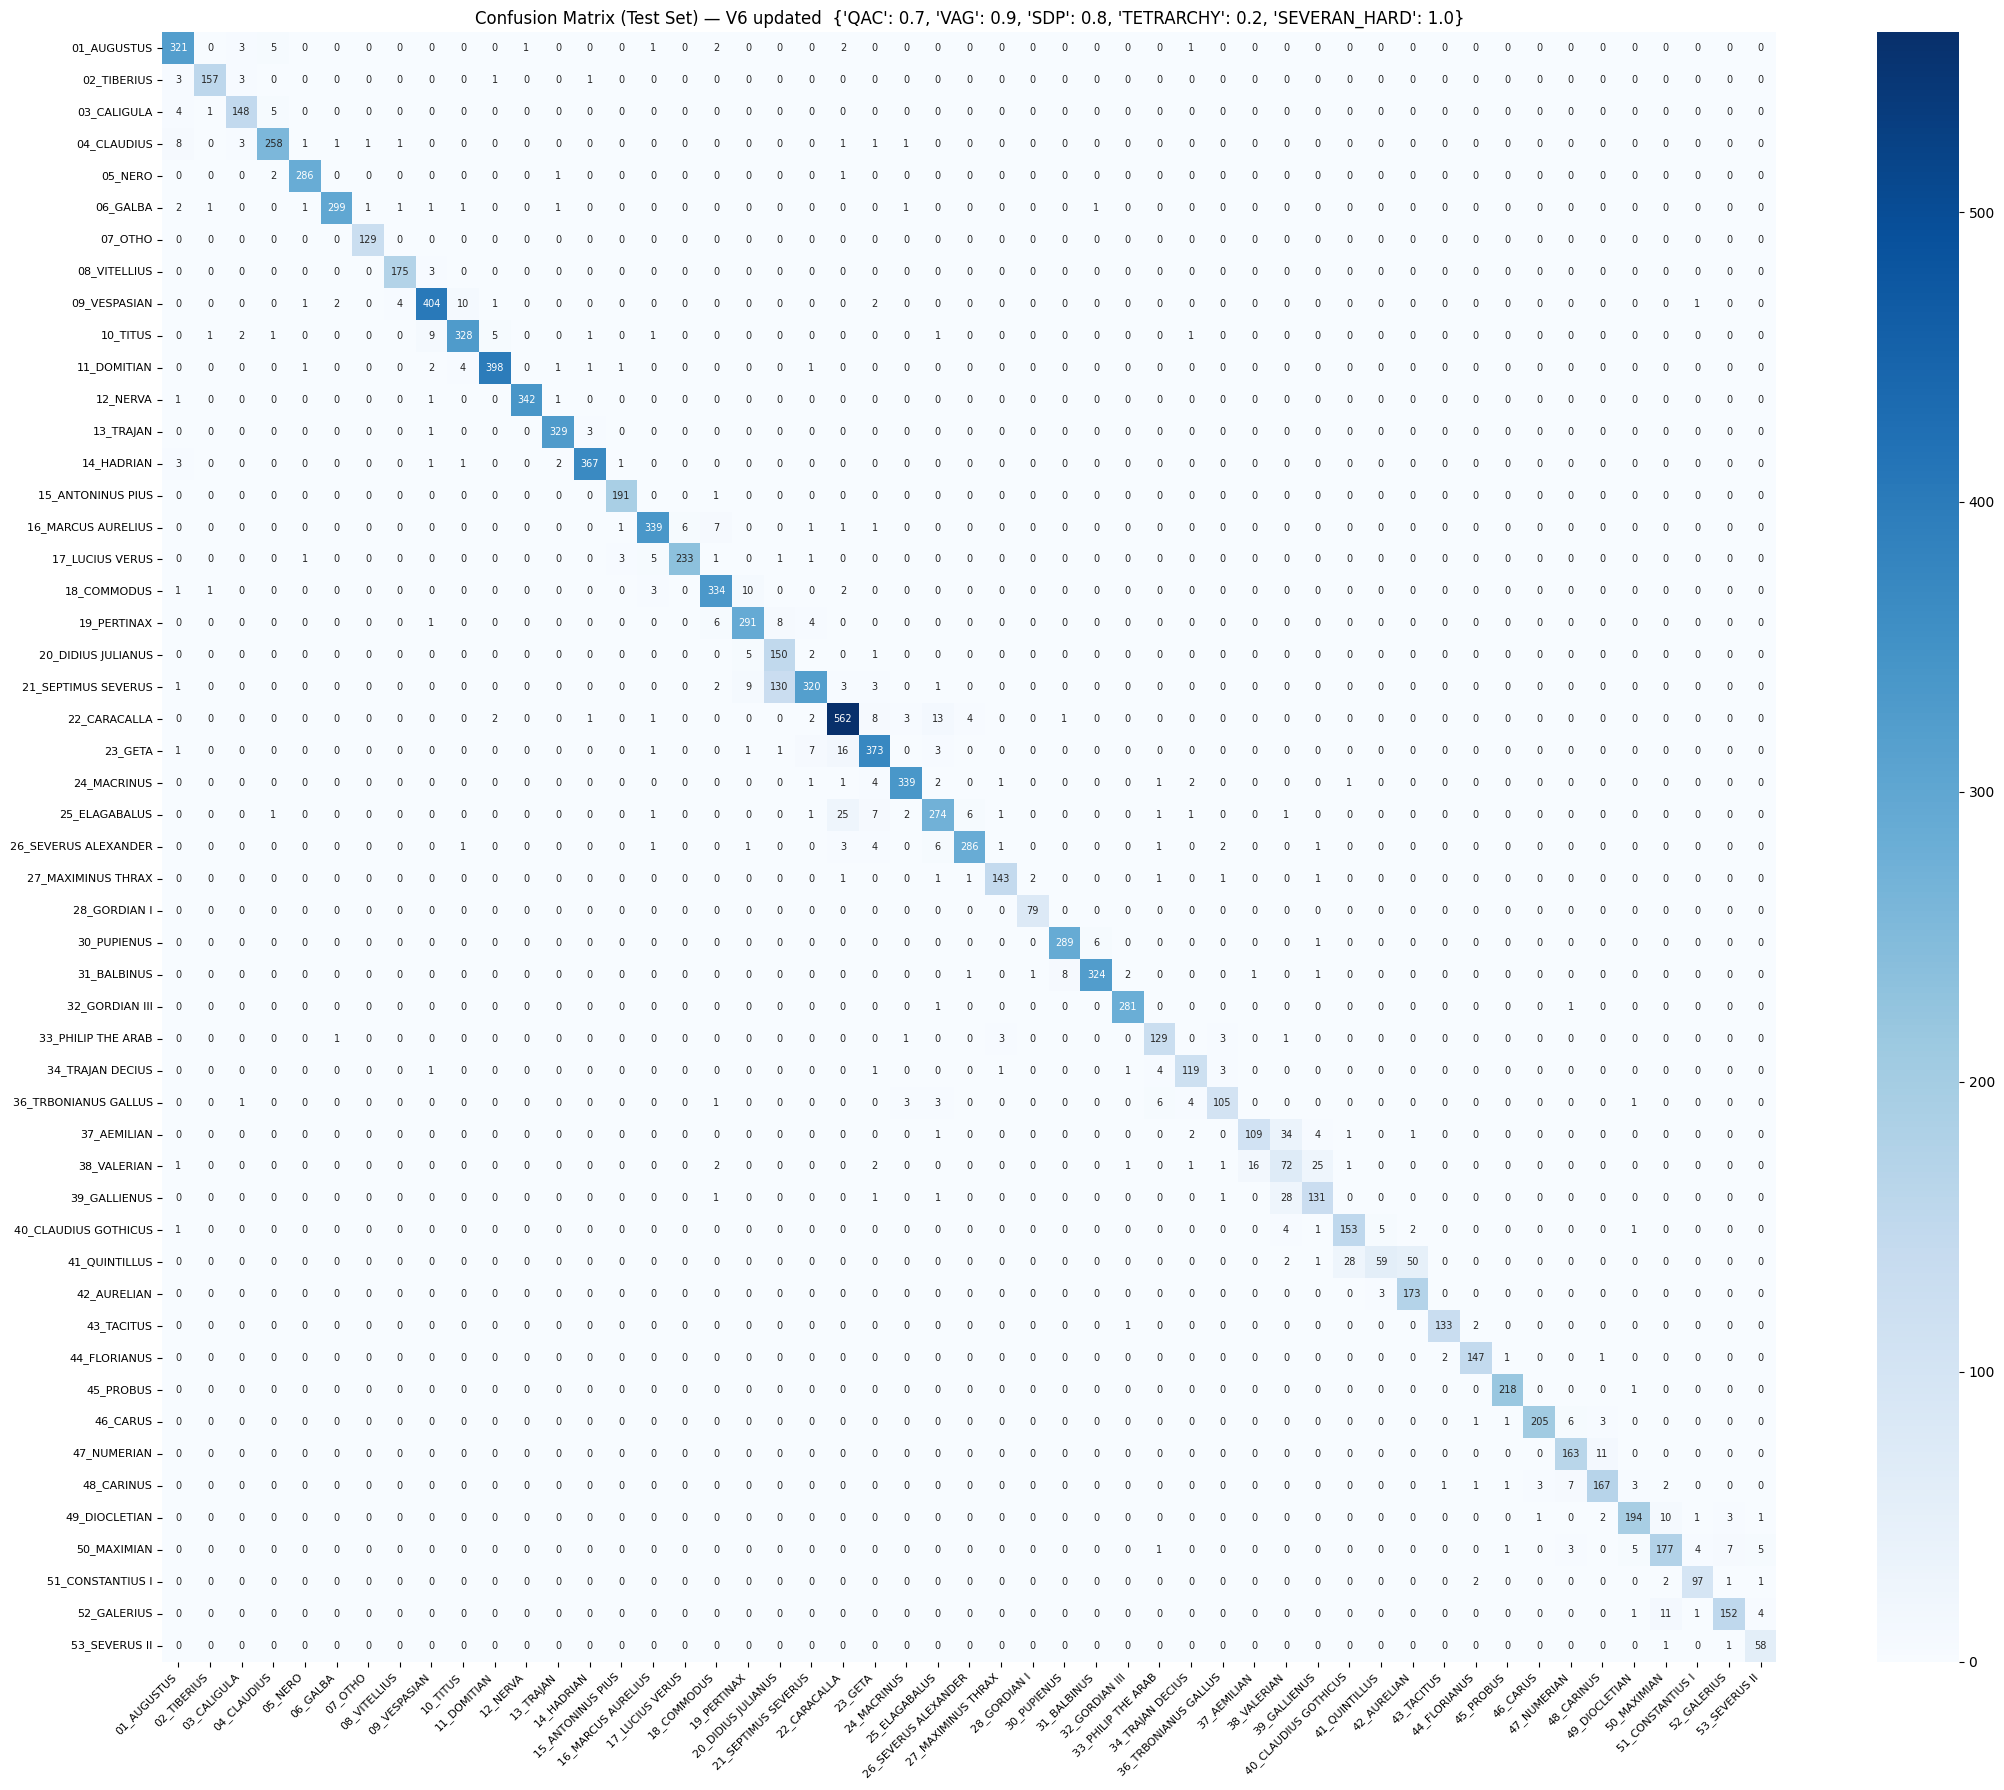

Overall test accuracy: 11510/12427 = 0.9262

41_QUINTILLUS: 59/140  acc=0.421
  → 42_AURELIAN: 50 (35.7%)
  → 40_CLAUDIUS GOTHICUS: 28 (20.0%)
  → 38_VALERIAN: 2 (1.4%)
  → other: 1

38_VALERIAN: 72/122  acc=0.590
  → 39_GALLIENUS: 25 (20.5%)
  → 37_AEMILIAN: 16 (13.1%)
  → 18_COMMODUS: 2 (1.6%)
  → other: 7

21_SEPTIMUS SEVERUS: 320/469  acc=0.682
  → 20_DIDIUS JULIANUS: 130 (27.7%)
  → 19_PERTINAX: 9 (1.9%)
  → 22_CARACALLA: 3 (0.6%)
  → other: 7

37_AEMILIAN: 109/152  acc=0.717
  → 38_VALERIAN: 34 (22.4%)
  → 39_GALLIENUS: 4 (2.6%)
  → 34_TRAJAN DECIUS: 2 (1.3%)
  → other: 3

39_GALLIENUS: 131/163  acc=0.804
  → 38_VALERIAN: 28 (17.2%)
  → 18_COMMODUS: 1 (0.6%)
  → 23_GETA: 1 (0.6%)
  → other: 2

36_TRBONIANUS GALLUS: 105/124  acc=0.847
  → 33_PHILIP THE ARAB: 6 (4.8%)
  → 34_TRAJAN DECIUS: 4 (3.2%)
  → 24_MACRINUS: 3 (2.4%)
  → other: 6

25_ELAGABALUS: 274/321  acc=0.854
  → 22_CARACALLA: 25 (7.8%)
  → 23_GETA: 7 (2.2%)
  → 26_SEVERUS ALEXANDER: 6 (1.9%)
  → other: 9

50_MAXIMIAN: 

In [66]:
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}

class_order   = sorted(range(num_classes), key=lambda i: name_to_prefix[idx_to_label[i]])
display_names = [f"{name_to_prefix[idx_to_label[i]]:02d}_{idx_to_label[i]}" for i in class_order]

cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for x_full, x_portrait, x_legend, targets in test_loader:
        targets = targets.to(device)
        preds   = two_stage_predict(x_full, x_portrait, x_legend,
                                     sub_weights=best_sw_per_cluster).argmax(-1)
        for t, p in zip(targets.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1
cm = cm[np.ix_(class_order, class_order)]

df_cm = pd.DataFrame(cm, index=display_names, columns=display_names)
plt.figure(figsize=(22, 18))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(f'Confusion Matrix (Test Set) — V6 updated  {best_sw_per_cluster}')
plt.tight_layout()
plt.show()

total_correct = int(cm.diagonal().sum())
total         = int(cm.sum())
print(f'Overall test accuracy: {total_correct}/{total} = {total_correct / total:.4f}')

TOP_CONFUSIONS = 3
row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
for i in np.argsort(row_acc):
    n_total   = int(cm[i].sum())
    n_correct = int(cm[i, i])
    acc_cls   = n_correct / max(n_total, 1)
    print(f'\n{display_names[i]}: {n_correct}/{n_total}  acc={acc_cls:.3f}')
    off = sorted(
        ((j, int(cm[i, j])) for j in range(num_classes) if j != i and cm[i, j] > 0),
        key=lambda x: -x[1],
    )
    if not off:
        print('  (no mistakes)')
        continue
    for j, count in off[:TOP_CONFUSIONS]:
        print(f'  → {display_names[j]}: {count} ({count / max(n_total, 1):.1%})')
    remaining = sum(c for _, c in off[TOP_CONFUSIONS:])
    if remaining:
        print(f'  → other: {remaining}')